# Tugas 3: Generasi Judul Berita dengan Encoder-Decoder dan Transformer
- Penulis: Ach. Nur Aqil Wahid
- Deskripsi singkat: Membangun tiga arsitektur model generatif untuk membuat judul dari artikel berita.

# Import Library

In [7]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load & Persiapan Dataset

In [8]:
# Tambahkan path project root ke Python path
project_root = os.path.abspath('..')  # karena notebook ada di dalam notebooks/
sys.path.append(project_root)

print("✔️ Path ditambahkan:", project_root)

✔️ Path ditambahkan: c:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita


In [9]:
file_path = r"C:\Users\aqilw\UGM\2. Semester 2\Pemrosesan Bahasa Alami Lanjut (PBAL)\3. Tugas Generasi Judul Berita\Generasi-Judul-Berita\data\newsapi_articles.json"

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

raw_inputs = [item['content'] for item in data if item['content'] and item['title']]
raw_targets = [item['title'] for item in data if item['content'] and item['title']]

print(f"Jumlah data: {len(raw_inputs)}")
print(f"Contoh judul: {raw_targets[0]}")

Jumlah data: 82
Contoh judul: The Verge is nominated for two Webby Awards — help us win them!


In [ ]:
from utils.preprocessing import (
    clean_text,
    prepare_tokenizer,
    encode_sequences,
    get_train_test_split
)

# Bersihkan teks
inputs = [clean_text(text) for text in raw_inputs]
targets = [f"<start> {clean_text(text)} <end>" for text in raw_targets]

# Tokenisasi
input_tokenizer, target_tokenizer = prepare_tokenizer(inputs, targets)

# Sequence dan padding
input_seq, target_seq = encode_sequences(
    input_tokenizer, target_tokenizer,
    inputs, targets,
    max_len_input=300,
    max_len_target=30
)

# Split
X_train, X_test, y_train, y_test = get_train_test_split(input_seq, target_seq)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 65 | Test size: 17


# Model 1: Encoder-Decoder LSTM

In [11]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

# Dapatkan ukuran vocab
input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=30
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_2 (InputLayer)           [(None, 30)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 300, 128)     167936      ['input_1[0][0]']                
                                                                                                  
 embedding_1 (Embedding)        (None, 30, 128)      78720       ['input_2[0][0]']                
                                                                                              

### Decoder Inputs & Outputs

In [12]:
import numpy as np

def create_decoder_data(target_seq):
    decoder_input_data = target_seq[:, :-1]  # semua kecuali token terakhir
    decoder_target_data = target_seq[:, 1:]  # semua kecuali token pertama
    return decoder_input_data, decoder_target_data

decoder_input_train, decoder_target_train = create_decoder_data(y_train)
decoder_input_test, decoder_target_test = create_decoder_data(y_test)

### Build & Compile Model

In [13]:
from models.encoder_decoder_lstm import build_lstm_seq2seq_model

input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

model = build_lstm_seq2seq_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29  # karena kita geser 1
)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_4 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 300, 128)     167936      ['input_3[0][0]']                
                                                                                                  
 embedding_3 (Embedding)        (None, 29, 128)      78720       ['input_4[0][0]']                
                                                                                            

### Latih Model

In [14]:
history = model.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),  # karena pakai sparse_categorical_crossentropy
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
4/4 [==============================] - 11s 397ms/step - loss: 6.3611 - accuracy: 0.4328 - val_loss: 6.1495 - val_accuracy: 0.5862
Epoch 2/20
4/4 [==============================] - 0s 57ms/step - loss: 5.1331 - accuracy: 0.6213 - val_loss: 3.2887 - val_accuracy: 0.5862
Epoch 3/20
4/4 [==============================] - 0s 53ms/step - loss: 2.8922 - accuracy: 0.6213 - val_loss: 3.1127 - val_accuracy: 0.5862
Epoch 4/20
4/4 [==============================] - 0s 53ms/step - loss: 2.6782 - accuracy: 0.6213 - val_loss: 2.8561 - val_accuracy: 0.5911
Epoch 5/20
4/4 [==============================] - 0s 59ms/step - loss: 2.5092 - accuracy: 0.6225 - val_loss: 2.9299 - val_accuracy: 0.5911
Epoch 6/20
4/4 [==============================] - 0s 61ms/step - loss: 2.4457 - accuracy: 0.6225 - val_loss: 3.0270 - val_accuracy: 0.5911
Epoch 7/20
4/4 [==============================] - 0s 55ms/step - loss: 2.4114 - accuracy: 0.6225 - val_loss: 3.0629 - val_accuracy: 0.5862
Epoch 8/20
4/4 [=========

### Visualisasi Training Loss & Akurasi

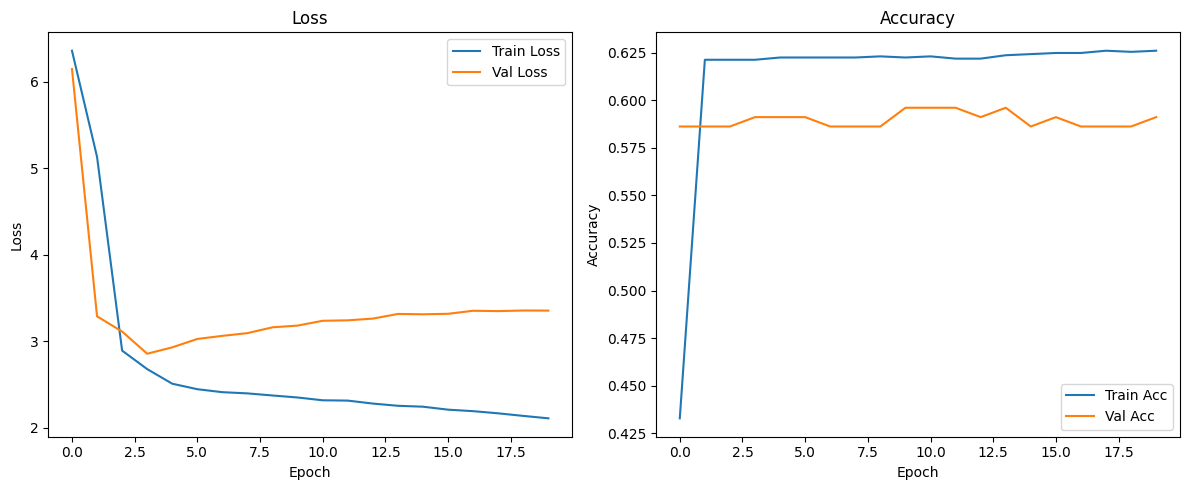

In [15]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Panggil fungsi
plot_training_history(history)


### Fungsi Inference (Generate Judul)

In [ ]:
def decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29):
    reverse_target_word_index = {i: w for w, i in target_tokenizer.word_index.items()}
    decoder_input = np.zeros((1, decoder_max_len))

    output_seq = model.predict([input_seq_single, decoder_input])
    output_tokens = np.argmax(output_seq[0], axis=-1)

    decoded_sentence = []
    for idx in output_tokens:
        word = reverse_target_word_index.get(idx, '')
        if word in ('<end>', ''):
            break
        if word != '<start>':
            decoded_sentence.append(word)
    
    return ' '.join(decoded_sentence)

### Generate Judul & Simpan ke CSV

In [17]:
# Ambil sampel dari test set
num_samples = len(X_test)
generated = []

for i in range(num_samples):    
    input_seq_single = np.expand_dims(X_test[i], axis=0)
    generated_title = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer)
    original_article = raw_inputs[i]
    actual_title = raw_targets[i]
    
    generated.append({
        'original_article': original_article,
        'actual_title': actual_title,
        'generated_title': generated_title
    })

# Simpan ke CSV
df_generated = pd.DataFrame(generated)
df_generated.to_csv('../outputs/generated_headlines.csv', index=False)

print("✅ Headline berhasil disimpan ke outputs/generated_headlines.csv")


1/1 [==============================] - 0s 41ms/step
✅ Headline berhasil disimpan ke outputs/generated_headlines.csv


-------------------

# Model 2: Encoder-Decoder + Attention

In [18]:
from models.encoder_decoder_attention import build_lstm_attention_model

model_attn = build_lstm_attention_model(
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    max_input_len=300,
    max_target_len=29
)

model_attn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_attn.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 300)]        0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 29)]         0           []                               
                                                                                                  
 embedding_4 (Embedding)        (None, 300, 128)     167936      ['input_5[0][0]']                
                                                                                                  
 embedding_5 (Embedding)        (None, 29, 128)      78720       ['input_6[0][0]']                
                                                                                            

### Train Model 2

In [19]:
history_attn = model_attn.fit(
    [X_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),
    validation_split=0.1,
    batch_size=16,
    epochs=20
)


Epoch 1/20
4/4 [==============================] - 4s 305ms/step - loss: 6.2916 - accuracy: 0.4465 - val_loss: 5.7627 - val_accuracy: 0.5862
Epoch 2/20
4/4 [==============================] - 0s 55ms/step - loss: 4.1382 - accuracy: 0.6213 - val_loss: 3.1316 - val_accuracy: 0.5862
Epoch 3/20
4/4 [==============================] - 0s 51ms/step - loss: 2.7304 - accuracy: 0.6213 - val_loss: 2.9073 - val_accuracy: 0.5862
Epoch 4/20
4/4 [==============================] - 0s 53ms/step - loss: 2.4985 - accuracy: 0.6213 - val_loss: 3.0119 - val_accuracy: 0.5862
Epoch 5/20
4/4 [==============================] - 0s 51ms/step - loss: 2.4331 - accuracy: 0.6213 - val_loss: 3.1713 - val_accuracy: 0.5862
Epoch 6/20
4/4 [==============================] - 0s 62ms/step - loss: 2.4154 - accuracy: 0.6213 - val_loss: 3.2851 - val_accuracy: 0.5862
Epoch 7/20
4/4 [==============================] - 0s 55ms/step - loss: 2.3720 - accuracy: 0.6213 - val_loss: 3.3206 - val_accuracy: 0.5862
Epoch 8/20
4/4 [==========

### Evaluate + Generate Headline

In [20]:
generated_title = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

1/1 [==============================] - 1s 679ms/step


In [21]:
df_generated.to_csv('../outputs/generated_headlines_attention.csv', index=False)

### Visualisasi Loss dan Akurasi Model 2

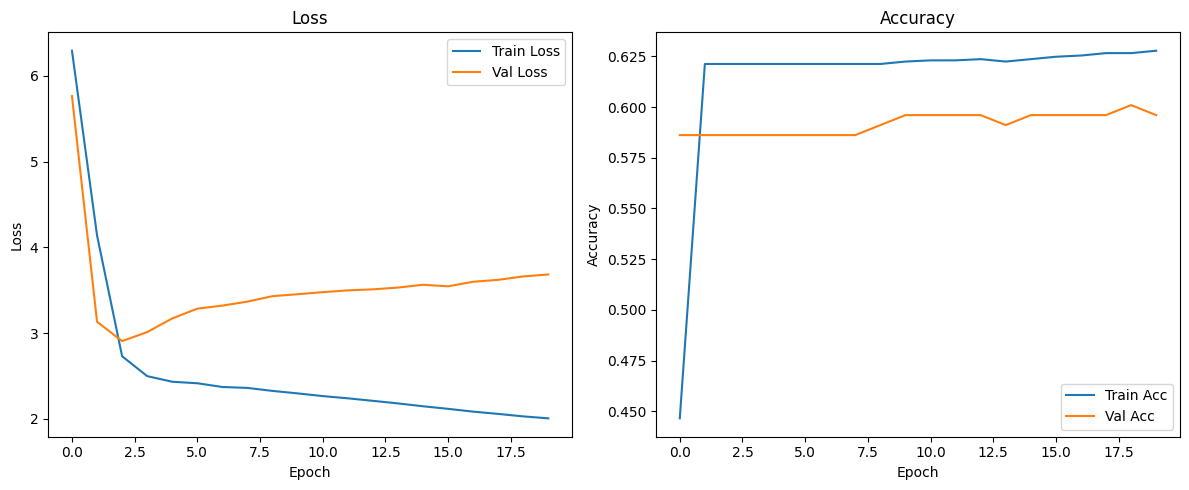

In [22]:
plot_training_history(history_attn)


### Perebandingan dua model dalam satu grafik

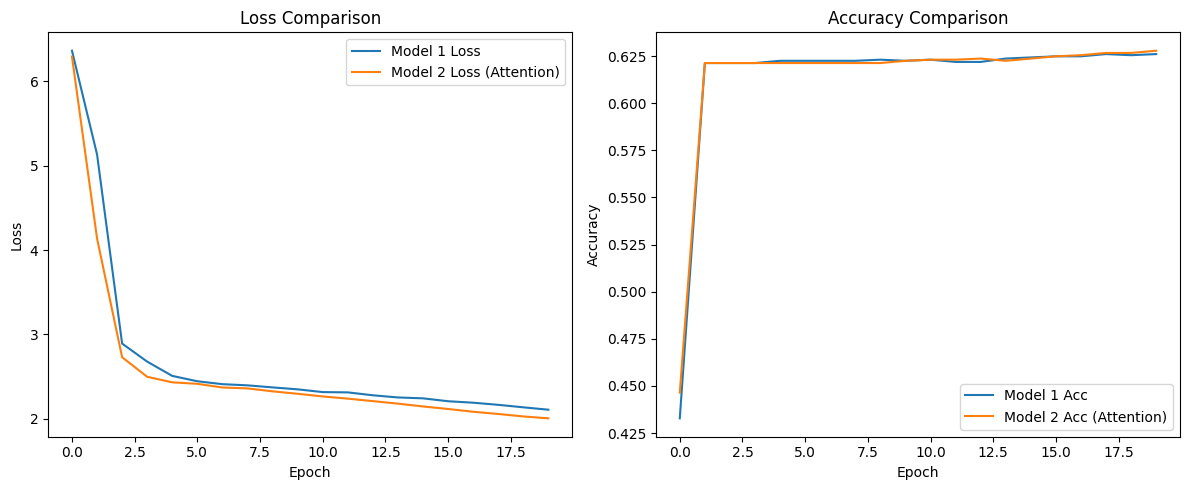

In [23]:
plt.figure(figsize=(12, 5))

# Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Model 1 Loss')
plt.plot(history_attn.history['loss'], label='Model 2 Loss (Attention)')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy Comparison
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Model 1 Acc')
plt.plot(history_attn.history['accuracy'], label='Model 2 Acc (Attention)')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### Evaluasi Kualitatif: Bandingkan Headline

In [24]:
from IPython.display import display, Markdown

for i in range(5):  # ambil 5 sampel untuk analisis
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    gen_title_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    gen_title_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)

    display(Markdown(f"""
**Artikel**:
{raw_inputs[i]}

**Judul Asli**:
🟢 {raw_targets[i]}

**Model 1 (tanpa Attention)**:
🔵 {gen_title_1}

**Model 2 (dengan Attention)**:
🟣 {gen_title_2}
---
"""))


1/1 [==============================] - 0s 39ms/step



**Artikel**:
Voting for the Peoples Voice Award ends on April 17th, 2025.
Voting for the Peoples Voice Award ends on April 17th, 2025.
The time of year has arrived Webby Award season. For the 29th annual Webby … [+1013 chars]

**Judul Asli**:
🟢 The Verge is nominated for two Webby Awards — help us win them!

**Model 1 (tanpa Attention)**:
🔵 to to to

**Model 2 (dengan Attention)**:
🟣 to to to
---


1/1 [==============================] - 0s 40ms/step



**Artikel**:
This is a recording of the keynote talk I gave at the Trenton Computer Festival on March 29, 2025. The theme of the festival was Fun With Technology and I talked about how Make and Maker Faire have b… [+26292 chars]

**Judul Asli**:
🟢 Fun With Technology

**Model 1 (tanpa Attention)**:
🔵 to to to

**Model 2 (dengan Attention)**:
🟣 to to to
---


1/1 [==============================] - 0s 39ms/step



**Artikel**:
Indian Prime Minister Narendra Modi said he discussed his country's potential to collaborate with the US on "technology and innovation" during a conversation with Elon Musk.
On Friday, Modi shared a… [+1815 chars]

**Judul Asli**:
🟢 PM Modi and Elon Musk talk India-US tech collaboration

**Model 1 (tanpa Attention)**:
🔵 to to to

**Model 2 (dengan Attention)**:
🟣 to to to
---


1/1 [==============================] - 0s 42ms/step



**Artikel**:
A NASA and CNES satellite lets scientists see the ocean floor in new ways. 
A NASA and CNES satellite lets scientists see the ocean floor in new ways. 
The world has a more detailed map of the seaf… [+2724 chars]

**Judul Asli**:
🟢 Watch this ultra-detailed animation of the seafloor

**Model 1 (tanpa Attention)**:
🔵 to to to

**Model 2 (dengan Attention)**:
🟣 to to to
---


1/1 [==============================] - 0s 41ms/step



**Artikel**:
The Game Developers Conference, an annual gathering that brings thousands of game developers to San Francisco, has just wrapped up. While most of the event is about networking and interesting talks a… [+5150 chars]

**Judul Asli**:
🟢 7 cool indie games from GDC 2025

**Model 1 (tanpa Attention)**:
🔵 to to to

**Model 2 (dengan Attention)**:
🟣 to to to
---


-----------------

# Model 3: Transformer

### Preprocessing Ulang Khusus untuk T5

In [25]:
from transformers import T5Tokenizer, TFT5ForConditionalGeneration
import tensorflow as tf

tokenizer_t5 = T5Tokenizer.from_pretrained("t5-small")
model_t5 = TFT5ForConditionalGeneration.from_pretrained("t5-small")

# Buat dataset input format: "summarize: <artikel>"
inputs_t5 = ["summarize: " + clean_text(text) for text in raw_inputs]
targets_t5 = [clean_text(text) for text in raw_targets]

# Split
from sklearn.model_selection import train_test_split
X_train_t5, X_test_t5, y_train_t5, y_test_t5 = train_test_split(inputs_t5, targets_t5, test_size=0.2, random_state=42)

All PyTorch model weights were used when initializing TFT5ForConditionalGeneration.

All the weights of TFT5ForConditionalGeneration were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFT5ForConditionalGeneration for predictions without further training.


### Inference: Generate Judul

In [29]:
def generate_title_t5(article_text, tokenizer, model):
    input_text = "summarize: " + clean_text(article_text)
    input_ids = tokenizer.encode(input_text, return_tensors="tf", max_length=512, truncation=True)
    outputs = model.generate(input_ids, max_length=30, num_beams=4, early_stopping=True)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Contoh
print(generate_title_t5(X_test_t5[0], tokenizer_t5, model_t5))


lilithe deal includes software called immigrationos to track visa overstays.


### Simpan ke CSV

In [30]:
t5_results = []

for i in range(len(X_test_t5)):
    gen_title = generate_title_t5(X_test_t5[i], tokenizer_t5, model_t5)
    t5_results.append({
        'original_article': X_test_t5[i],
        'actual_title': y_test_t5[i],
        'generated_title': gen_title
    })

df_t5 = pd.DataFrame(t5_results)
df_t5.to_csv('../outputs/generated_headlines_t5.csv', index=False)


# Evaluasi & Analisis

In [31]:
from IPython.display import Markdown, display

for i in range(5):
    input_seq_single = np.expand_dims(X_test[i], axis=0)

    pred_1 = decode_sequence(input_seq_single, model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_2 = decode_sequence(input_seq_single, model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    pred_3 = generate_title_t5(X_test_t5[i], tokenizer_t5, model_t5)

    display(Markdown(f"""
### 📰 Sampel #{i+1}
**🟠 Artikel:**
{raw_inputs[i]}

**🟢 Judul Asli:**
{raw_targets[i]}

**🔵 Model 1 (LSTM):**  
{pred_1}

**🟣 Model 2 (LSTM + Attention):**  
{pred_2}

**🟡 Model 3 (Transformer T5):**  
{pred_3}
---
"""))


1/1 [==============================] - 0s 81ms/step



### 📰 Sampel #1
**🟠 Artikel:**
Voting for the Peoples Voice Award ends on April 17th, 2025.
Voting for the Peoples Voice Award ends on April 17th, 2025.
The time of year has arrived Webby Award season. For the 29th annual Webby … [+1013 chars]

**🟢 Judul Asli:**
The Verge is nominated for two Webby Awards — help us win them!

**🔵 Model 1 (LSTM):**  
to to to

**🟣 Model 2 (LSTM + Attention):**  
to to to

**🟡 Model 3 (Transformer T5):**  
lilithe deal includes software called immigrationos to track visa overstays.
---


1/1 [==============================] - 0s 44ms/step



### 📰 Sampel #2
**🟠 Artikel:**
This is a recording of the keynote talk I gave at the Trenton Computer Festival on March 29, 2025. The theme of the festival was Fun With Technology and I talked about how Make and Maker Faire have b… [+26292 chars]

**🟢 Judul Asli:**
Fun With Technology

**🔵 Model 1 (LSTM):**  
to to to

**🟣 Model 2 (LSTM + Attention):**  
to to to

**🟡 Model 3 (Transformer T5):**  
voting for the peoples voice award ends on april 17th, 2025.
---


1/1 [==============================] - 0s 42ms/step



### 📰 Sampel #3
**🟠 Artikel:**
Indian Prime Minister Narendra Modi said he discussed his country's potential to collaborate with the US on "technology and innovation" during a conversation with Elon Musk.
On Friday, Modi shared a… [+1815 chars]

**🟢 Judul Asli:**
PM Modi and Elon Musk talk India-US tech collaboration

**🔵 Model 1 (LSTM):**  
to to to

**🟣 Model 2 (LSTM + Attention):**  
to to to

**🟡 Model 3 (Transformer T5):**  
the marine corps' top general sent a video reminder out to the force this week. it points to russian disasters in
---


1/1 [==============================] - 0s 43ms/step



### 📰 Sampel #4
**🟠 Artikel:**
A NASA and CNES satellite lets scientists see the ocean floor in new ways. 
A NASA and CNES satellite lets scientists see the ocean floor in new ways. 
The world has a more detailed map of the seaf… [+2724 chars]

**🟢 Judul Asli:**
Watch this ultra-detailed animation of the seafloor

**🔵 Model 1 (LSTM):**  
to to to

**🟣 Model 2 (LSTM + Attention):**  
to to to

**🟡 Model 3 (Transformer T5):**  
elon musk is hoping to implant computer chips in human 4135 chars.
---


1/1 [==============================] - 0s 46ms/step



### 📰 Sampel #5
**🟠 Artikel:**
The Game Developers Conference, an annual gathering that brings thousands of game developers to San Francisco, has just wrapped up. While most of the event is about networking and interesting talks a… [+5150 chars]

**🟢 Judul Asli:**
7 cool indie games from GDC 2025

**🔵 Model 1 (LSTM):**  
to to to

**🟣 Model 2 (LSTM + Attention):**  
to to to

**🟡 Model 3 (Transformer T5):**  
one rumor suggests it may have another feature that has yet to appear in another apple phone a camera embedded under the screen.
---


### Evaluasi Objektif (ROUGE Score)

In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
scores_1, scores_2, scores_3 = [], [], []

for i in range(len(X_test)):
    reference = raw_targets[i]

    # Predictions
    p1 = decode_sequence(np.expand_dims(X_test[i], axis=0), model, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p2 = decode_sequence(np.expand_dims(X_test[i], axis=0), model_attn, input_tokenizer, target_tokenizer, decoder_max_len=29)
    p3 = generate_title_t5(X_test_t5[i], tokenizer_t5, model_t5)

    scores_1.append(scorer.score(reference, p1))
    scores_2.append(scorer.score(reference, p2))
    scores_3.append(scorer.score(reference, p3))

def avg_rouge(scores, key='rougeL'):
    return sum([s[key].fmeasure for s in scores]) / len(scores)

print(f"Model 1 - ROUGE-L: {avg_rouge(scores_1):.4f}")
print(f"Model 2 - ROUGE-L: {avg_rouge(scores_2):.4f}")
print(f"Model 3 - ROUGE-L: {avg_rouge(scores_3):.4f}")


1/1 [==============================] - 0s 43ms/step


# Simpulan

1. Pendahuluan
   - Penjelasan tugas dan dataset (NewsAPI)

2. Model & Arsitektur
   - Model 1: LSTM klasik
   - Model 2: LSTM + Attention
   - Model 3: Transformer T5 (pretrained)

3. Hasil
   - Visualisasi loss & akurasi
   - Kualitas prediksi (manual)
   - Skor ROUGE (objektif)

4. Diskusi
   - Model 2 lebih baik dari Model 1 karena mampu fokus
   - Model 3 menghasilkan bahasa lebih natural, walau tidak dilatih khusus
   - Kompromi antara efisiensi komputasi dan kualitas

5. Kesimpulan
   - T5 recommended untuk kecepatan
   - Attention memberi dampak signifikan pada LSTM
